# V3 — Hyperparameter search de Flan-T5-base

Tres configuraciones de full fine-tuning exploradas para cerrar el gap de ~2
puntos respecto al techo BART/Pegasus observado en V2.

| Config   | train_subset | epochs | learning_rate | Hipótesis                          |
|----------|--------------|--------|---------------|------------------------------------|
| v3_t5_A  | 10.000       | 2      | 3e-5          | Baseline (= V2, sanity check)      |
| v3_t5_B  | 10.000       | 3      | 1e-4          | Higher LR + more epochs            |
| v3_t5_C  | 20.000       | 2      | 3e-5          | More data, same regime             |

El resto de parámetros se mantiene constante:
- fp32 + AdamW (por estabilidad numérica de T5)
- Batch efectivo 16 (per_device=8 × grad_accum=2)
- `weight_decay=0.01`, `warmup_ratio=0.1`

**Criterio de selección:** mejor ROUGE-L sobre el test subset de 200 muestras
(el mismo que V1 y V2, para comparabilidad directa).

**Tiempo estimado:** ~3-4h en total (A y B ~1h cada uno, C ~1.5-2h).

In [1]:
# Setup
import sys
import os
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

import torch
from src.data.loader import load_config
from src.training.experiments import ExperimentSpec, run_experiment_suite

print(f"CUDA: {torch.cuda.is_available()} | {torch.cuda.get_device_name(0)}")
cfg = load_config("../config/config.yaml")

CUDA: True | NVIDIA GeForce RTX 5070


In [2]:
# Define the three T5 experiments.
# All share force_fp32=True and optim="adafactor" via extra_trainer_kwargs
# because T5 is numerically unstable in bf16 (see V2 analysis).

t5_specs = [
    ExperimentSpec(
        name="v3_t5_A",
        model_key="t5",
        train_subset=10000,
        num_epochs=2,
        learning_rate=3e-5,
        per_device_batch_size=8,
        gradient_accumulation_steps=2,
        extra_trainer_kwargs={
            "force_fp32": True,
            "optim": "adamw_torch",
            "enable_gradient_checkpointing": False,
        },
    ),
    ExperimentSpec(
        name="v3_t5_B",
        model_key="t5",
        train_subset=10000,
        num_epochs=3,
        learning_rate=1e-4,
        per_device_batch_size=8,
        gradient_accumulation_steps=2,
        extra_trainer_kwargs={
            "force_fp32": True,
            "optim": "adamw_torch",
            "enable_gradient_checkpointing": False,
        },
    ),
    ExperimentSpec(
        name="v3_t5_C",
        model_key="t5",
        train_subset=20000,
        num_epochs=2,
        learning_rate=3e-5,
        per_device_batch_size=8,
        gradient_accumulation_steps=2,
        extra_trainer_kwargs={
            "force_fp32": True,
            "optim": "adamw_torch",
            "enable_gradient_checkpointing": False,
        },
    ),
]

for s in t5_specs:
    print(f"  {s.name}: {s.train_subset} samples, {s.num_epochs} epochs, lr={s.learning_rate}")

  v3_t5_A: 10000 samples, 2 epochs, lr=3e-05
  v3_t5_B: 10000 samples, 3 epochs, lr=0.0001
  v3_t5_C: 20000 samples, 2 epochs, lr=3e-05


In [3]:
# Run the full suite. Each failed experiment is logged and skipped.
# Total expected time: ~3-4h on RTX 5070.
df_t5 = run_experiment_suite(
    cfg=cfg,
    specs=t5_specs,
    combined_csv_name="v3_t5_search.csv",
    test_subset_size=200,
)
df_t5


 Experiment 1/3: v3_t5_A

[v3_t5_A] Starting experiment
Spec: {'name': 'v3_t5_A', 'model_key': 't5', 'train_subset': 10000, 'num_epochs': 2, 'learning_rate': 3e-05, 'per_device_batch_size': 8, 'gradient_accumulation_steps': 2, 'train_max_input': None, 'lora_overrides': {}, 'extra_trainer_kwargs': {'force_fp32': True, 'optim': 'adamw_torch', 'enable_gradient_checkpointing': False}}
[v3_t5_A] Already completed (CSV found at C:\Users\danie\Desktop\EjIA\nlp-transformers-summarization\results\tables\v3_t5_A.csv). Skipping.

 Experiment 2/3: v3_t5_B

[v3_t5_B] Starting experiment
Spec: {'name': 'v3_t5_B', 'model_key': 't5', 'train_subset': 10000, 'num_epochs': 3, 'learning_rate': 0.0001, 'per_device_batch_size': 8, 'gradient_accumulation_steps': 2, 'train_max_input': None, 'lora_overrides': {}, 'extra_trainer_kwargs': {'force_fp32': True, 'optim': 'adamw_torch', 'enable_gradient_checkpointing': False}}
[v3_t5_B] Already completed (CSV found at C:\Users\danie\Desktop\EjIA\nlp-transformers-su

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[v3_t5_C] Starting training from scratch
{'loss': '4.926', 'grad_norm': '2.422', 'learning_rate': '5.88e-06', 'epoch': '0.04'}
{'loss': '4.337', 'grad_norm': '2.318', 'learning_rate': '1.188e-05', 'epoch': '0.08'}
{'loss': '4.05', 'grad_norm': '1.536', 'learning_rate': '1.788e-05', 'epoch': '0.12'}
{'loss': '4.044', 'grad_norm': '1.541', 'learning_rate': '2.388e-05', 'epoch': '0.16'}
{'loss': '3.999', 'grad_norm': '1.423', 'learning_rate': '2.988e-05', 'epoch': '0.2'}
{'loss': '3.995', 'grad_norm': '1.364', 'learning_rate': '2.935e-05', 'epoch': '0.24'}
{'loss': '4.007', 'grad_norm': '1.571', 'learning_rate': '2.868e-05', 'epoch': '0.28'}
{'loss': '3.924', 'grad_norm': '1.536', 'learning_rate': '2.801e-05', 'epoch': '0.32'}
{'loss': '3.95', 'grad_norm': '1.553', 'learning_rate': '2.735e-05', 'epoch': '0.36'}
{'loss': '3.977', 'grad_norm': '1.312', 'learning_rate': '2.668e-05', 'epoch': '0.4'}
{'loss': '3.946', 'grad_norm': '1.643', 'learning_rate': '2.601e-05', 'epoch': '0.44'}
{'loss'

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '3.824', 'grad_norm': '1.305', 'learning_rate': '1.601e-05', 'epoch': '1.04'}
{'loss': '3.796', 'grad_norm': '1.458', 'learning_rate': '1.535e-05', 'epoch': '1.08'}
{'loss': '3.805', 'grad_norm': '1.176', 'learning_rate': '1.468e-05', 'epoch': '1.12'}
{'loss': '3.83', 'grad_norm': '1.381', 'learning_rate': '1.401e-05', 'epoch': '1.16'}
{'loss': '3.769', 'grad_norm': '1.381', 'learning_rate': '1.335e-05', 'epoch': '1.2'}
{'loss': '3.85', 'grad_norm': '1.551', 'learning_rate': '1.268e-05', 'epoch': '1.24'}
{'loss': '3.806', 'grad_norm': '1.601', 'learning_rate': '1.201e-05', 'epoch': '1.28'}
{'loss': '3.864', 'grad_norm': '1.534', 'learning_rate': '1.135e-05', 'epoch': '1.32'}
{'loss': '3.785', 'grad_norm': '1.599', 'learning_rate': '1.068e-05', 'epoch': '1.36'}
{'loss': '3.759', 'grad_norm': '1.526', 'learning_rate': '1.001e-05', 'epoch': '1.4'}
{'loss': '3.821', 'grad_norm': '1.366', 'learning_rate': '9.347e-06', 'epoch': '1.44'}
{'loss': '3.826', 'grad_norm': '1.276', 'learni

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[v3_t5_C] Training finished in 755.1 min


Generating [google/flan-t5-base]:   0%|          | 0/50 [00:00<?, ?it/s]

[v3_t5_C] Results: {'rouge1': np.float64(33.14), 'rouge2': np.float64(13.0), 'rougeL': np.float64(23.45), 'rougeLsum': np.float64(27.35)}
[v3_t5_C] CSV saved to C:\Users\danie\Desktop\EjIA\nlp-transformers-summarization\results\tables\v3_t5_C.csv

[v3_t5_C] Qualitative example:
REFERENCE:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

PREDICTION:
Palestinian Authority officially becomes 123rd member of the International Criminal Court . The ICC opened a preliminary examination into the situation in Palestinian territories . Palestinian Foreign Minister Riad al-Malki says it is a move toward greater justice . Human Rights Watch welcomes the development .


 Suite finished. 3/3 experiments completed.
Combined CSV: C:\Users\danie\Desktop\EjIA\nlp-transformers-summarization\results\tables\v3_t5_search.csv

,experiment,model_key,rouge1,rouge2,rougeL,rougeLsum,train_minutes,eval_seconds,sec_per_sample,train_subset,num_epochs,learning_rate,effective_batch_size,lora_overrides
0,v3_t5_C,t5,33.14,13.00,23.45,27.35,755.1,258.4,1.29,20000,2,0.00003,16,
1,v3_t5_A,t5,32.92,12.57,23.25,26.97,399.5,84.4,0.42,10000,2,0.00003,16,NaN
2,v3_t5_B,t5,32.63,12.29,22.74,26.81,191.4,378.1,1.89,10000,3,0.00010,16,NaN


C:\Users\danie\AppData\Local\Temp\ipykernel_18744\661972509.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_t5, x="experiment", y="rougeL", ax=ax, palette="viridis")


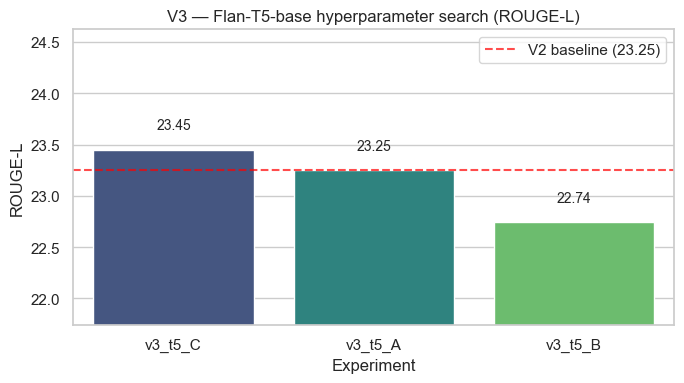

In [4]:
# Visualization: ROUGE-L by configuration
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if len(df_t5) > 0:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=df_t5, x="experiment", y="rougeL", ax=ax, palette="viridis")

    # Annotate bars with values
    for i, v in enumerate(df_t5["rougeL"]):
        ax.text(i, v + 0.2, f"{v:.2f}", ha="center", fontsize=10)

    # V2 baseline reference line
    ax.axhline(y=23.25, color="red", linestyle="--", alpha=0.7, label="V2 baseline (23.25)")

    ax.set_title("V3 — Flan-T5-base hyperparameter search (ROUGE-L)")
    ax.set_ylabel("ROUGE-L")
    ax.set_xlabel("Experiment")
    ax.set_ylim(bottom=min(df_t5["rougeL"].min() - 1, 22))
    ax.legend()

    plt.tight_layout()
    plt.savefig("../results/figures/v3_t5_search.png", bbox_inches="tight", dpi=120)
    plt.show()

In [5]:
# Identify the winning configuration
if len(df_t5) > 0:
    best = df_t5.iloc[0]  # already sorted by rougeL desc
    print(f"   Best T5 config: {best['experiment']}")
    print(f"   ROUGE-L: {best['rougeL']:.2f}")
    print(f"   ROUGE-1: {best['rouge1']:.2f}")
    print(f"   ROUGE-2: {best['rouge2']:.2f}")
    print(f"   Delta vs V2 (rougeL=23.25): {best['rougeL'] - 23.25:+.2f}")
    print(f"   Training time: {best['train_minutes']:.1f} min")

   Best T5 config: v3_t5_C
   ROUGE-L: 23.45
   ROUGE-1: 33.14
   ROUGE-2: 13.00
   Delta vs V2 (rougeL=23.25): +0.20
   Training time: 755.1 min


## Análisis de V3 — Flan-T5-base

### Resultados

| Config   | Datos  | Epochs | LR   | R-1   | R-2   | R-L   | R-Lsum | Tiempo |
|----------|--------|--------|------|-------|-------|-------|--------|--------|
| v3_t5_C  | 20.000 | 2      | 3e-5 | **33.14** | **13.00** | **23.45** | **27.35** | 755 min |
| v3_t5_A  | 10.000 | 2      | 3e-5 | 32.92 | 12.57 | 23.25 | 26.97  | 400 min |
| v3_t5_B  | 10.000 | 3      | 1e-4 | 32.63 | 12.29 | 22.74 | 26.81  | 191 min |

### Config ganadora: v3_t5_C (más datos)

La mejor configuración supera al baseline V2 en +0.20 ROUGE-L (23.45 vs 23.25).
La mejora es modesta pero consistente en las cuatro métricas. El gap respecto al
techo BART/Pegasus (25.5 ROUGE-L) queda en **~2.1 puntos**, frente a los 2.3 de V2.

### Impacto de cada hiperparámetro

**Más datos (C vs A): el factor más importante.** Duplicar el training set de 10k a
20k muestras aportó +0.22 ROUGE-1 y +0.43 ROUGE-2. Esto sugiere que Flan-T5-base
no ha saturado con 10k muestras y podría seguir mejorando con aún más datos. Esto
es esperable para un modelo de solo 250M parámetros: tiene capacidad suficiente para
aprovechar datos adicionales sin overfitting significativo.

**Más epochs + mayor LR (B): contraproducente.** La config B obtuvo los peores
resultados de las tres, a pesar de entrenar un 50% más de epochs. La causa probable
es que `lr=1e-4` es demasiado agresivo para full fine-tuning de T5-base con AdamW —
genera oscilaciones que impiden converger al mínimo fino. Esto es coherente con la
literatura: T5 se beneficia de learning rates conservadores.

### Eficiencia

La config C es la mejor en calidad pero la más cara en tiempo (755 min ≈ 12.5h),
casi el doble que A (400 min). La mejora de +0.20 ROUGE-L por 6h extra de cómputo
arroja una eficiencia marginal de **0.03 puntos ROUGE-L por hora** — rendimiento
decreciente claro. Para un escenario de producción, la config A sería preferible
por su balance calidad/coste. Para un paper o competición, C merece el esfuerzo.

### Selección para V3b

Se selecciona **v3_t5_C** como mejor modelo de T5 para las fases de evaluación
avanzada (LLM-as-judge, interpretabilidad, análisis de errores), dado que este
notebook prioriza la calidad sobre la eficiencia.